In [1]:
print('Hello World')

Hello World


In [39]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import boxcox
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer


In [11]:
df = pd.read_csv("Titanic-cleaned.csv",usecols = ['Age','Fare','Survived'])


In [14]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [15]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [18]:
print(df[['Age','Fare']].skew())

Age     0.548256
Fare    4.787317
dtype: float64


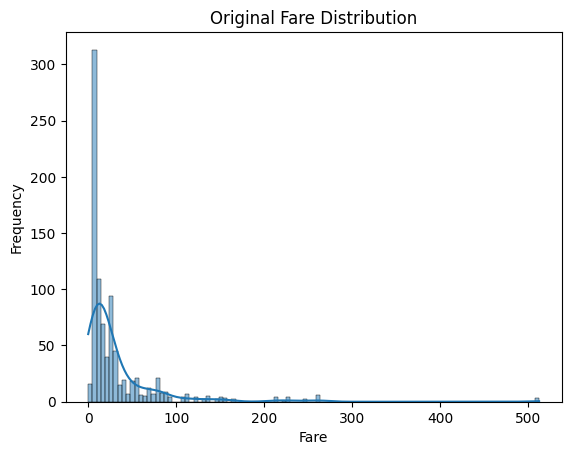

In [21]:
sns.histplot(df['Fare'], kde=True)
plt.title("Original Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

In [22]:
df['fare_log'] = np.log1p(df['Fare'])
print(df[['Fare','fare_log']].head())

      Fare  fare_log
0   7.2500  2.110213
1  71.2833  4.280593
2   7.9250  2.188856
3  53.1000  3.990834
4   8.0500  2.202765


In [34]:
print("Log Skewness : ",df['fare_log'].skew())

Log Skewness :  0.3949280095189306


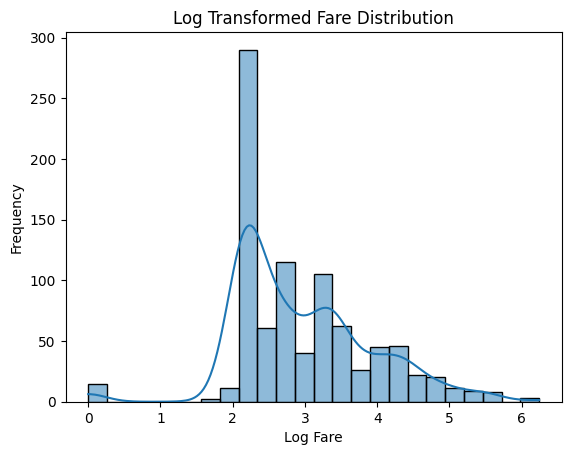

In [25]:
sns.histplot(df['fare_log'], kde=True)
plt.title("Log Transformed Fare Distribution")
plt.xlabel("Log Fare")
plt.ylabel("Frequency")
plt.show()

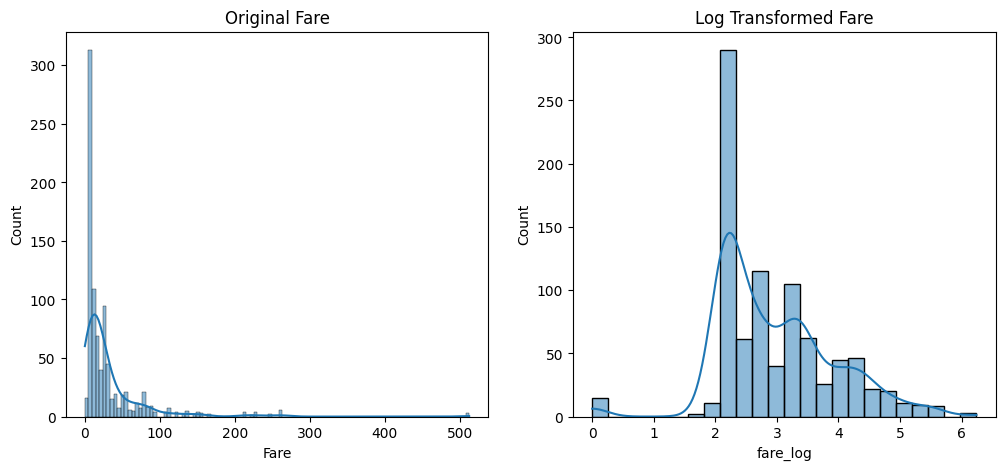

In [28]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Fare'], kde=True)
plt.title("Original Fare")

plt.subplot(1,2,2)
sns.histplot(df['fare_log'], kde=True)
plt.title("Log Transformed Fare")

plt.show()

In [30]:
df['fare_boxcox'], lambda_value = boxcox(df['Fare']+1)
print("Lambda : ",lambda_value)

Lambda :  -0.09778702173339403


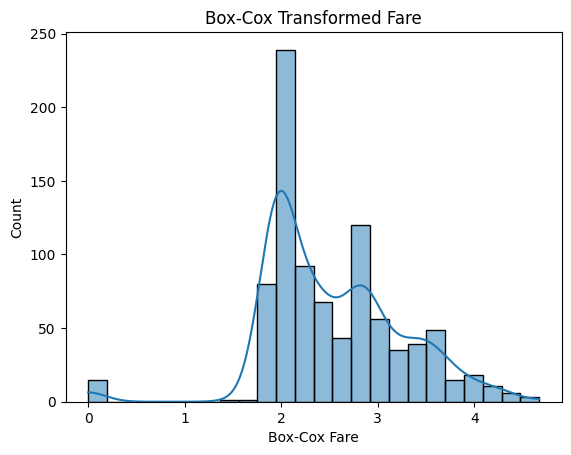

In [31]:
sns.histplot(df['fare_boxcox'], kde=True)
plt.title("Box-Cox Transformed Fare")
plt.xlabel("Box-Cox Fare")
plt.ylabel("Count")
plt.show()

In [32]:
print("Original Skewness:", df['Fare'].skew())

Original Skewness: 4.787316519674893


In [35]:
print("Boxcox Skewness:", df['fare_boxcox'].skew())
print("Log Skewness : ",df['fare_log'].skew())

Boxcox Skewness: -0.04032915137340004
Log Skewness :  0.3949280095189306


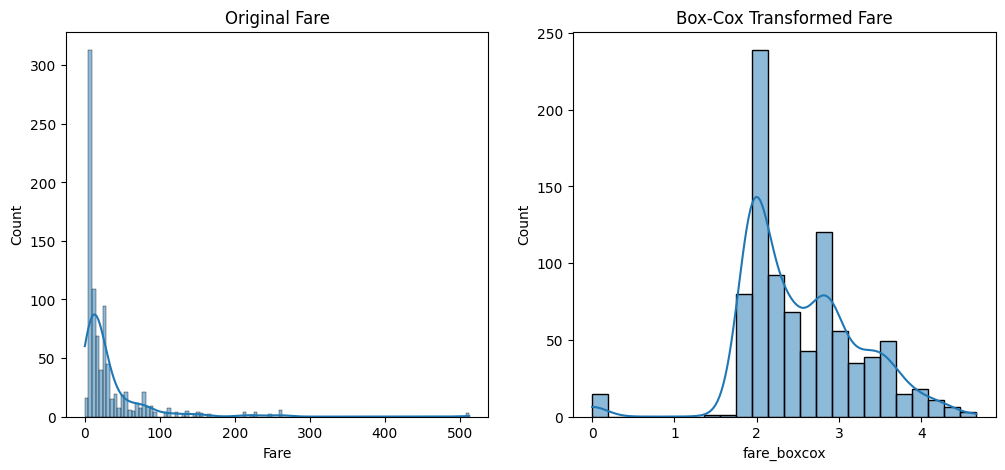

In [36]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Fare'], kde=True)
plt.title("Original Fare")

plt.subplot(1,2,2)
sns.histplot(df['fare_boxcox'], kde=True)
plt.title("Box-Cox Transformed Fare")

plt.show()

In [38]:
print("Original:", df['Fare'].skew())
print("Log:", df['fare_log'].skew())
print("Boxcox:", df['fare_boxcox'].skew())

Original: 4.787316519674893
Log: 0.3949280095189306
Boxcox: -0.04032915137340004


In [43]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [44]:
print("Skewness of Amount:", df['Amount'].skew())

Skewness of Amount: 16.977724453761024


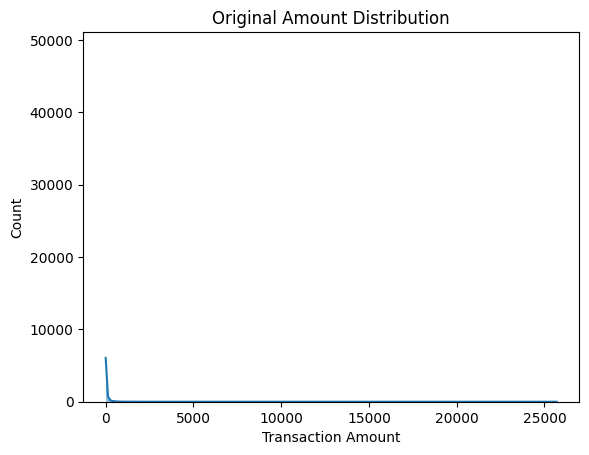

In [47]:
sns.histplot(df['Amount'], kde=True)
plt.title("Original Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")
plt.show()

In [48]:
pt = PowerTransformer(method="yeo-johnson")
df['amount_yeojohnson'] = pt.fit_transform(df[['Amount']])

In [50]:
print("Yeo-Johnson Skew:", df['amount_yeojohnson'].skew())

Yeo-Johnson Skew: 0.018354105402808712


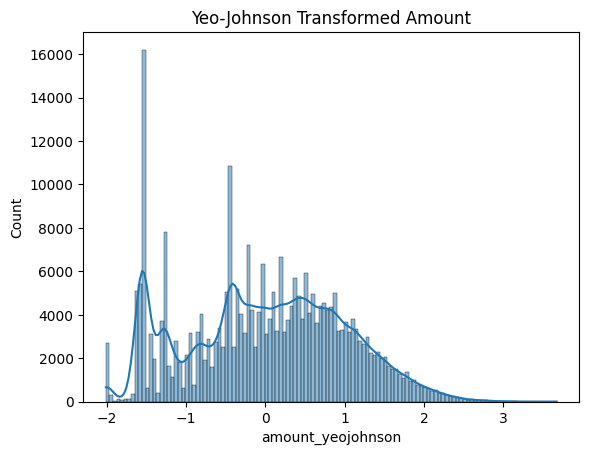

In [52]:
sns.histplot(df['amount_yeojohnson'], kde=True)
plt.title("Yeo-Johnson Transformed Amount")
plt.show()